In [1]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE

DISTINCT_COLORS = [
    "#E6194B",  
    "#3CB44B", 
    "#4363D8", 
    "#F58231",  
    "#911EB4",  
]
SEED = 42

In [2]:
original_data   = np.load('../duomenys/original_data.npy')
labels          = np.load('../duomenys/ship-types.npy')
distance_matrix = np.load('../duomenys/dist_mat.npy')

In [3]:
unique_labels, labels_encoded = np.unique(labels, return_inverse=True)
label_names = {i: name for i, name in enumerate(unique_labels)}

n_samples = original_data.shape[0]
original_flat = original_data.reshape(n_samples, -1)

all_classes = np.unique(labels_encoded)
class_colors = {cls: DISTINCT_COLORS[i % len(DISTINCT_COLORS)]
                for i, cls in enumerate(all_classes)}

embedding = TSNE(
    perplexity=50,
    early_exaggeration=4,
    learning_rate=10,
    max_iter=2000,
    n_components=2,
    random_state=SEED
).fit_transform(distance_matrix)

In [4]:
from sklearn.model_selection import train_test_split

original_flat = original_data.reshape((-1, original_data.shape[1]*original_data.shape[2]))
X_train, X_test, y_train, y_test, emb_train, emb_test = train_test_split(
    original_flat, labels_encoded, embedding, test_size=0.3, random_state=SEED, stratify=labels_encoded
)

In [5]:
import pandas as pd

In [6]:
from sklearn.metrics import confusion_matrix

In [7]:
def run_random_forest(X_train, X_test, y_train, y_test, label_names, **params):

    rf = RandomForestClassifier(**params)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*60}")
    for param, v in params.items():
        print(f"{param} : {v}")
    print(f"{'='*60}")
    print("Klasifikavimo lentele (true/pred)")
    cm_df = pd.DataFrame(cm)
    print(cm_df.to_string())

    n       = cm.sum()
    diag    = np.diag(cm)
    rowsums = cm.sum(axis=1)
    colsums = cm.sum(axis=0)

    precision = np.where(colsums > 0, diag / colsums, 0.0)
    recall    = np.where(rowsums > 0, diag / rowsums, 0.0)
    f1        = np.where((precision + recall) > 0,
                         2 * precision * recall / (precision + recall), 0.0)
    accuracy  = diag.sum() / n

    print("\nMetrikos kiekvienai klasei:")
    print(pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                       index=[label_names[c] for c in range(5)]).round(4).to_string())
    print(f"\nAccuracy      : {accuracy:.4f}")
    print(f"Macro precision : {precision.mean():.4f}")
    print(f"Macro recall    : {recall.mean():.4f}")
    print(f"Macro F1        : {f1.mean():.4f}")

    return rf

In [8]:
rf_orig = run_random_forest(X_train, X_test, y_train, y_test, label_names)


Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  36   1   1   3   4
1   9  33   0   0   3
2   3   0  39   2   1
3   1   0   2  42   0
4   7   2   1   0  35

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.6429  0.8000  0.7129
Fishing       0.9167  0.7333  0.8148
Passenger     0.9070  0.8667  0.8864
Pilot         0.8936  0.9333  0.9130
Tanker        0.8140  0.7778  0.7955

Accuracy      : 0.8222
Macro precision : 0.8348
Macro recall    : 0.8222
Macro F1        : 0.8245


In [9]:
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(
    embedding, labels_encoded, test_size=0.3, random_state=SEED, stratify=labels_encoded
)

In [10]:
rf_proj = run_random_forest(X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne, label_names)


Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  27   5   5   3   5
1  12  28   0   1   4
2   3   2  35   3   2
3   2   0   3  37   3
4  10   3   6   0  26

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.5000  0.6000  0.5455
Fishing       0.7368  0.6222  0.6747
Passenger     0.7143  0.7778  0.7447
Pilot         0.8409  0.8222  0.8315
Tanker        0.6500  0.5778  0.6118

Accuracy      : 0.6800
Macro precision : 0.6884
Macro recall    : 0.6800
Macro F1        : 0.6816


In [11]:
import matplotlib.colors as mcolors

In [12]:
def plot_decision_boundary(
    clf, 
    X_test_sc,
    y_test,
    label_names,
    title,
    ax,
    unique_classes,
    step=0.3
):

    x_min = X_test_sc[:,0].min() - 1
    x_max = X_test_sc[:,0].max() + 1
    y_min = X_test_sc[:,1].min() - 1
    y_max = X_test_sc[:,1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    class_to_idx = {c: i for i, c in enumerate(unique_classes)}
    Z_idx = np.array([class_to_idx[z] for z in Z]).reshape(xx.shape)
    n_classes = len(unique_classes)
    bg_cmap = mcolors.ListedColormap([class_colors[c] for c in unique_classes])
    ax.contourf(xx, yy, Z_idx, alpha=0.25, cmap=bg_cmap,
                levels=np.arange(-0.5, n_classes, 1))

    # Mokymo taškai
    for cls in unique_classes:
        mask = y_test == cls
        ax.scatter(X_test_sc[mask, 0], X_test_sc[mask, 1],
                   c=class_colors[cls], edgecolors='k', s=60,
                   label=label_names[cls], zorder=3)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=7, loc="best")




In [13]:
import matplotlib.pyplot as plt

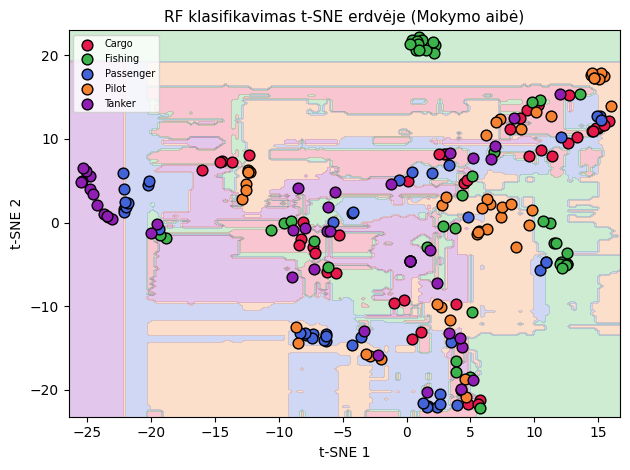

In [14]:
fig, ax = plt.subplots()

plot_decision_boundary(
    rf_proj, X_test_tsne, y_test_tsne, label_names, unique_classes=all_classes,
    title="RF klasifikavimas t-SNE erdvėje (Mokymo aibė)",
    ax=ax
)

plt.tight_layout()
plt.savefig('rf-klasifikavimo-pavirsius.png', dpi=750)

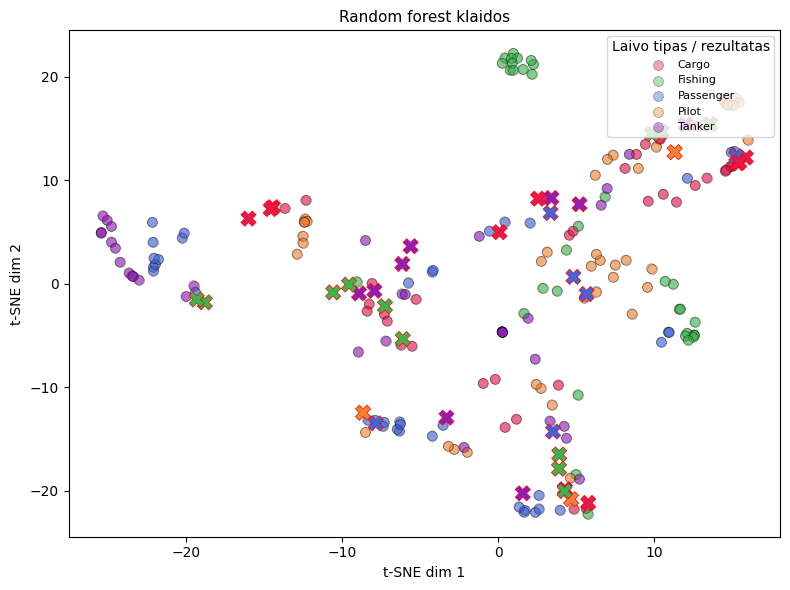

In [15]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred = rf_orig.predict(X_test)
correct = y_pred == y_test 

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(emb_test[correct, 0], emb_test[correct, 1],
            c=[class_colors[c] for c in y_test[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

for cls in unique_cls:
    mask = correct & (y_test == cls)
    ax2.scatter(
        emb_test[mask, 0], emb_test[mask, 1],
        c=class_colors[cls], s=50, edgecolors='k', linewidths=0.5,
        marker='o', alpha=0.4, zorder=2,
        label=unique_labels[cls]
    )

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(
    emb_test[~correct, 0], emb_test[~correct, 1],
    c=[class_colors[c] for c in y_test[~correct]],
    s=120, edgecolors='red', linewidths=0.5, marker='X', alpha=1.0, zorder=3
)
ax2.legend(fontsize=8, loc='upper right', title="Laivo tipas / rezultatas")

ax2.set_title("Random forest klaidos", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/rf_errors_orig.svg', format='svg')
plt.show()


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

param_grid = {
    'n_estimators': [20, 75, 100, 200],
    'max_depth':    [None, 8, 32, 64],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Best params:  {grid_search.best_params_}")
print(f"Best CV acc:  {grid_search.best_score_:.4f}")

# Full results as a sorted DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)
cols = ['param_n_estimators', 'param_max_depth',
        'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
print(results_df[cols].sort_values('rank_test_score').to_string(index=False))

# ── Best model ready to use ───────────────────────────────────────────────────
rf_best = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Best params:  {'max_depth': None, 'n_estimators': 200}
Best CV acc:  0.8095
 param_n_estimators param_max_depth  mean_train_score  mean_test_score  std_test_score  rank_test_score
                200            None          1.000000         0.809524        0.015936                1
                200              32          1.000000         0.809524        0.015936                1
                200              64          1.000000         0.809524        0.015936                1
                 75               8          0.939524         0.801905        0.020337                4
                200               8          0.945714         0.800000        0.018070                5
                100              32          1.000000         0.800000        0.017037                5
                100            None          1.000000         0.800000        0.017037                5
                 75            None          1.000000         0.800000        0.024094      

In [17]:
est = rf_orig.estimators_
depths = [estimator.tree_.max_depth for estimator in est]

max(depths)

20

> Geriausias hiperparametrų rinkinys - 200 medžių ir neribotas medžio gylis (didžiausias gautas gylis - 23)

In [18]:
rf_optim = run_random_forest(X_train, X_test, y_train, y_test, label_names,
                            **grid_search.best_params_)


max_depth : None
n_estimators : 200
Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  37   1   0   3   4
1  10  32   0   0   3
2   4   0  38   2   1
3   1   0   2  41   1
4  10   1   1   0  33

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.5968  0.8222  0.6916
Fishing       0.9412  0.7111  0.8101
Passenger     0.9268  0.8444  0.8837
Pilot         0.8913  0.9111  0.9011
Tanker        0.7857  0.7333  0.7586

Accuracy      : 0.8044
Macro precision : 0.8284
Macro recall    : 0.8044
Macro F1        : 0.8090


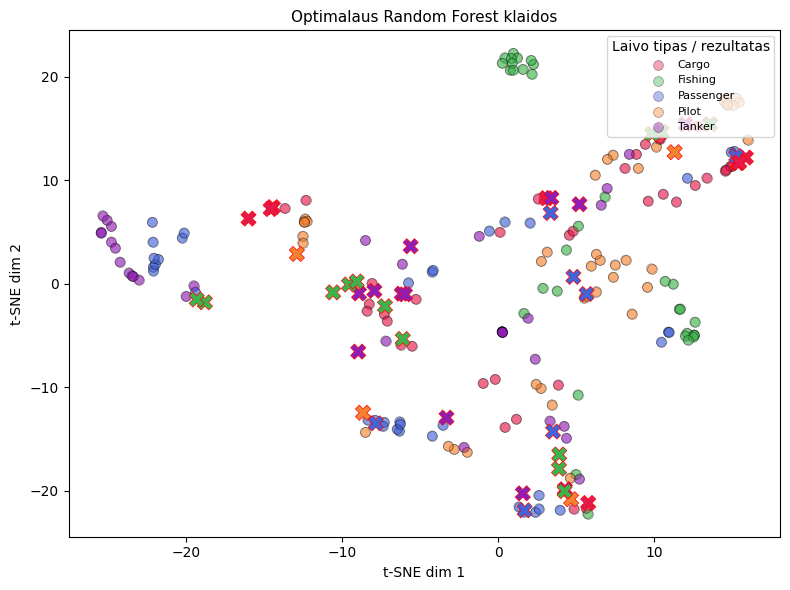

In [19]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred = rf_optim.predict(X_test)
correct = y_pred == y_test 

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(emb_test[correct, 0], emb_test[correct, 1],
            c=[class_colors[c] for c in y_test[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

for cls in unique_cls:
    mask = correct & (y_test == cls)
    ax2.scatter(
        emb_test[mask, 0], emb_test[mask, 1],
        c=class_colors[cls], s=50, edgecolors='k', linewidths=0.5,
        marker='o', alpha=0.4, zorder=2,
        label=unique_labels[cls]
    )

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(
    emb_test[~correct, 0], emb_test[~correct, 1],
    c=[class_colors[c] for c in y_test[~correct]],
    s=120, edgecolors='red', linewidths=0.5, marker='X', alpha=1.0, zorder=3
)
ax2.legend(fontsize=8, loc='upper right', title="Laivo tipas / rezultatas")

ax2.set_title("Optimalaus Random Forest klaidos", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/rf_errors_orig.svg', format='svg')
plt.show()


In [20]:
unique_cls = np.unique(labels_encoded)
y_pred = rf_optim.predict(X_test)
correct = y_pred == y_test 

class_data = {
    'correct': {},
    'incorrect': {}
}

for cls in unique_cls:
    class_data['correct'][cls] = np.mean(X_test\
        .reshape((-1, 25, 10))\
        [correct & (y_test == cls)], axis=0
    ).mean(axis=0)

    class_data['incorrect'][cls] = np.mean(X_test\
        .reshape((-1, 25, 10))\
        [~correct & (y_test == cls)], axis=0
    ).mean(axis=0)

df = pd.DataFrame(
    {(status, label): values
     for status, classes in class_data.items()
     for label, values in classes.items()}
)

df['correct', 'feature_number'] = np.arange(df.shape[0])
df['incorrect', 'feature_number'] = np.arange(df.shape[0])

df_correct = df['correct'].melt(id_vars='feature_number', var_name='class', value_name='mean_value')
df_correct['status'] = 'correct'

df_incorrect = df['incorrect'].melt(id_vars='feature_number', var_name='class', value_name='mean_value')
df_incorrect['status'] = 'incorrect'

comparison_df = pd.concat([df_correct, df_incorrect], ignore_index=True)

In [21]:
pivot_df = comparison_df.pivot_table(
    index=['feature_number', 'class'],
    columns='status',
    values='mean_value'
).reset_index()

pivot_df.columns.name = None

pivot_df = pivot_df.rename(columns={
    'correct': 'mean_correct',
    'incorrect': 'mean_incorrect'
})

pivot_df['difference'] = pivot_df['mean_correct'] - pivot_df['mean_incorrect']
pivot_df['abs_difference'] = pivot_df['difference'].abs()

pivot_df = pivot_df.sort_values('abs_difference', ascending=False)

print(pivot_df.to_string(index=False))

 feature_number  class  mean_correct  mean_incorrect    difference  abs_difference
              3      3      0.100488        0.443275 -3.427869e-01    3.427869e-01
              5      1      0.711546        0.440851  2.706947e-01    2.706947e-01
              3      1      0.106144        0.344106 -2.379621e-01    2.379621e-01
              1      4      0.504626        0.267149  2.374775e-01    2.374775e-01
              7      3      0.692620        0.482259  2.103605e-01    2.103605e-01
              3      2      0.523111        0.312847  2.102637e-01    2.102637e-01
              1      0      0.217094        0.409185 -1.920910e-01    1.920910e-01
              1      2      0.385763        0.199139  1.866233e-01    1.866233e-01
              8      3      0.007070        0.183836 -1.767661e-01    1.767661e-01
              4      2      0.759744        0.590449  1.692950e-01    1.692950e-01
              4      4      0.852004        0.705994  1.460104e-01    1.460104e-01
    

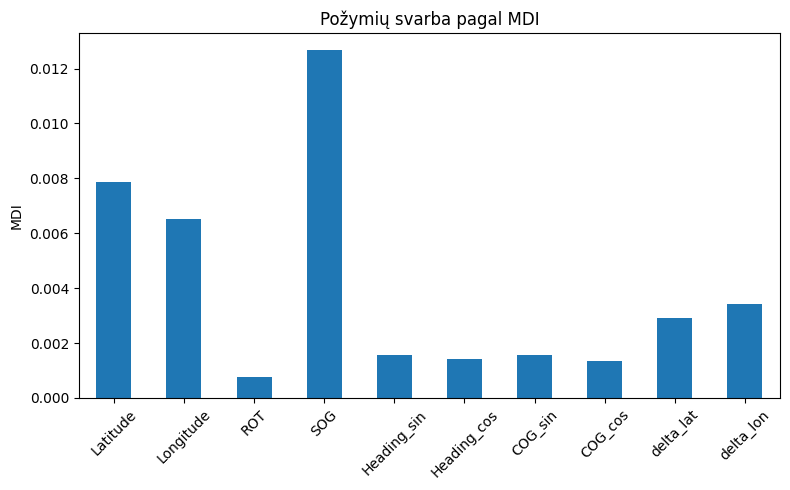

In [22]:
n_timesteps = original_data.shape[1]  # 25
n_features  = original_data.shape[2]  # 10
feature_names_short = [
    'Latitude', 'Longitude', 'ROT',
    'SOG', 'Heading_sin', 'Heading_cos',
    'COG_sin', 'COG_cos', 'delta_lat', 'delta_lon'
]

# (250,) -> (25, 10) 
imp_2d = rf_optim.feature_importances_.reshape(n_timesteps, n_features)
std_2d = np.std(
    [tree.feature_importances_.reshape(n_timesteps, n_features)
     for tree in rf_optim.estimators_], axis=0
)

importances_agg = imp_2d.mean(axis=0)   
# std_agg         = std_2d.mean(axis=0)   

forest_importances = pd.Series(importances_agg, index=feature_names_short)

fig, ax = plt.subplots(figsize=(8, 5))
forest_importances.plot.bar(yerr=0, ax=ax)
ax.set_title("Požymių svarba pagal MDI") # (aggregated over timesteps)
ax.set_ylabel("MDI")
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()

SOG and Latitude are clearly the most important features for distinguishing ship types.
Longitude is moderately important.
ROT, Heading, COG, delta_lat, delta_lon contribute relatively little.
The large error bars on SOG and Latitude mean their importance varies a lot depending on which timestep — which is exactly what the heatmap explains.

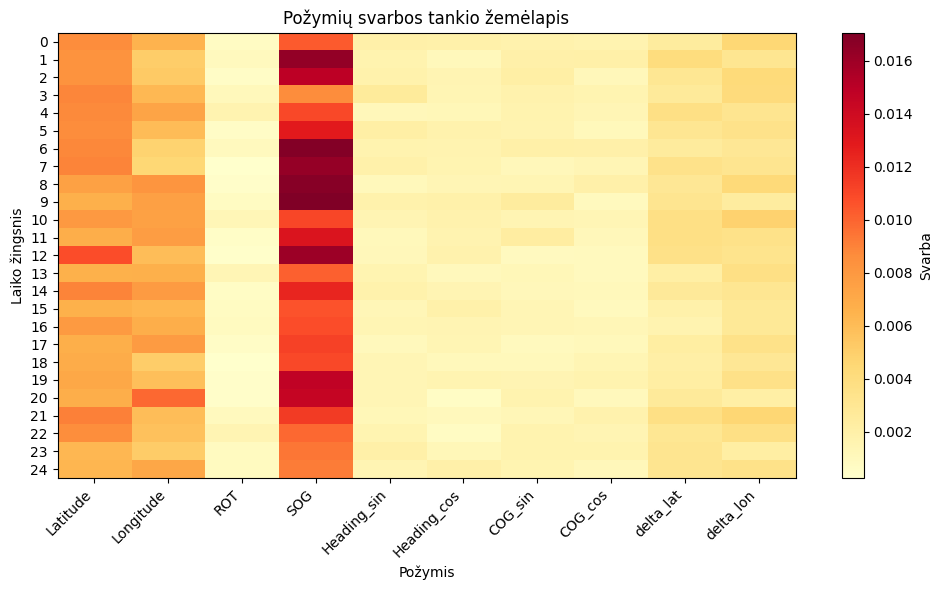

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(imp_2d, aspect='auto', cmap='YlOrRd')

ax.set_xlabel("Požymis")
ax.set_ylabel("Laiko žingsnis")
ax.set_title("Požymių svarbos tankio žemėlapis")

ax.set_xticks(range(n_features))
ax.set_xticklabels(feature_names_short, rotation=45, ha="right")

ax.set_yticks(range(n_timesteps))

plt.colorbar(im, ax=ax, label="Svarba")

fig.tight_layout()
plt.show()

SOG is the single most discriminative feature, and critically it matters most at timesteps 9–13 and 20–24 (the middle and end of the trajectory window), not at the most recent observation.
Latitude is consistently important across almost all timesteps — ships of different types tend to operate in different geographic zones
Longitude  matters most at earlier timesteps (0–8), then fades.
Everything else (ROT, Heading, COG, deltas) is largely uniform and pale — low importance throughout.

The practical takeaway: ship type is primarily encoded in how fast the ship is moving (SOG) and where it is geographically (Latitude), not in its heading or rate of turn.

In [24]:
from sklearn.feature_selection import RFECV

In [25]:
rf_rfe_cv = RFECV(
    estimator=RandomForestClassifier(n_estimators=75, max_depth=None, random_state=100),
    min_features_to_select=50,
    step=25,
    n_jobs=-1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=100)
)


rf_rfe_cv.fit(
    X_train, y_train
)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,RandomForestC...dom_state=100)
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",25
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",50
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",75
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None


In [26]:
features = np.array([
    f'{feat}-{step}'
    for step in range(25)
    for feat in feature_names_short
])
features[rf_rfe_cv.support_]

array(['Latitude-0', 'Longitude-0', 'SOG-0', 'Heading_cos-0',
       'delta_lat-0', 'delta_lon-0', 'Latitude-1', 'Longitude-1', 'SOG-1',
       'delta_lat-1', 'delta_lon-1', 'Latitude-2', 'SOG-2',
       'Heading_cos-2', 'delta_lat-2', 'delta_lon-2', 'Latitude-3',
       'Longitude-3', 'SOG-3', 'delta_lon-3', 'Latitude-4', 'Longitude-4',
       'SOG-4', 'COG_sin-4', 'delta_lat-4', 'delta_lon-4', 'Latitude-5',
       'Longitude-5', 'SOG-5', 'delta_lat-5', 'delta_lon-5', 'Latitude-6',
       'Longitude-6', 'SOG-6', 'Heading_sin-6', 'COG_sin-6',
       'delta_lat-6', 'Latitude-7', 'Longitude-7', 'SOG-7', 'delta_lat-7',
       'delta_lon-7', 'Latitude-8', 'Longitude-8', 'SOG-8', 'COG_cos-8',
       'delta_lon-8', 'Latitude-9', 'Longitude-9', 'SOG-9', 'delta_lon-9',
       'Latitude-10', 'Longitude-10', 'SOG-10', 'Heading_sin-10',
       'Heading_cos-10', 'delta_lat-10', 'delta_lon-10', 'Latitude-11',
       'Longitude-11', 'SOG-11', 'COG_sin-11', 'COG_cos-11',
       'delta_lat-11', 'delta

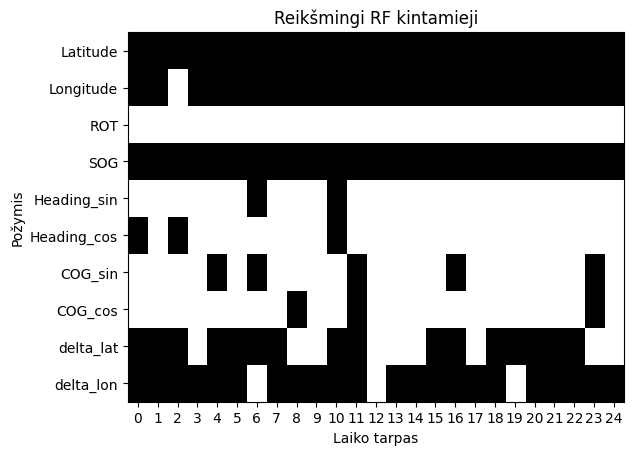

In [27]:
fig, ax = plt.subplots()

ax.imshow( 
    rf_rfe_cv.support_.reshape(25, 10).T,
    cmap='binary', aspect='auto'
)

ax.set_ylabel("Požymis")
ax.set_xlabel("Laiko tarpas")
ax.set_yticks(ticks=range(10), labels=feature_names_short)
ax.set_xticks(range(25))

ax.set_title('Reikšmingi RF kintamieji')

plt.show()

In [28]:
rf_final = rf_rfe_cv.estimator
rf_final.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",75
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [29]:
y_pred = rf_final.predict(original_flat)
correct_all = y_pred == labels_encoded

In [30]:
mmsis = np.load('../duomenys/mmsi-sarasas.npy', allow_pickle=True)

print(f"MMSIs per trajectory check: {mmsis.shape}")  # should be (750,)

print("\nMisclassified MMSIs:")

MISCLASSIFIED_PREDS = {}

for i in np.where(~correct_all)[0]:
    true_label = label_names[labels_encoded[i]]
    pred_label = label_names[y_pred[i]]
    mmsi = mmsis[i]
    print(f"  MMSI {mmsi}  |  true: {true_label:20s}  |  predicted: {pred_label}")

    if mmsi not in MISCLASSIFIED_PREDS:
        MISCLASSIFIED_PREDS[mmsi] = [pred_label]
    else:
        MISCLASSIFIED_PREDS[mmsi].append( pred_label )

MMSIs per trajectory check: (750,)

Misclassified MMSIs:
  MMSI 266435000  |  true: Cargo                 |  predicted: Fishing
  MMSI 538012153  |  true: Cargo                 |  predicted: Tanker
  MMSI 244234000  |  true: Cargo                 |  predicted: Tanker
  MMSI 266435000  |  true: Cargo                 |  predicted: Tanker
  MMSI 257186000  |  true: Cargo                 |  predicted: Pilot
  MMSI 244234000  |  true: Cargo                 |  predicted: Tanker
  MMSI 305445000  |  true: Cargo                 |  predicted: Tanker
  MMSI 265019000  |  true: Fishing               |  predicted: Cargo
  MMSI 211325510  |  true: Fishing               |  predicted: Cargo
  MMSI 273397450  |  true: Fishing               |  predicted: Cargo
  MMSI 211325510  |  true: Fishing               |  predicted: Cargo
  MMSI 265028000  |  true: Fishing               |  predicted: Cargo
  MMSI 219707000  |  true: Fishing               |  predicted: Cargo
  MMSI 219030955  |  true: Fishing     

In [31]:
import numpy as np
import pandas as pd
import folium

CSV_PATH      = '../duomenys/data.csv'
OUTPUT_HTML   = 'trajectories_npy_rf.html'

MMSIS_PATH         = '../duomenys/mmsis.npy'
SHIP_INDICES_PATH  = '../duomenys/ship_indices.npy'
ORIGINAL_DATA_PATH = '../duomenys/original_data.npy'
SHIP_TYPES_PATH    = '../duomenys/ship-types.npy'

# Dict: MMSI -> [predicted_labels]  (true label comes from ship_types[i])
MISCLASSIFIED_MMSIS = set(MISCLASSIFIED_PREDS.keys())

TYPE_COLORS = {
    'Cargo':     '#4363D8',
    'Fishing':   '#3CB44B',
    'Passenger': '#F58231',
    'Pilot':     '#911EB4',
    'Tanker':    '#E6194B',
}

print("Loading npy files...")
mmsis         = np.load(MMSIS_PATH, allow_pickle=True)
ship_indices  = np.load(SHIP_INDICES_PATH, allow_pickle=True)
original_data = np.load(ORIGINAL_DATA_PATH, allow_pickle=True)
ship_types    = np.load(SHIP_TYPES_PATH, allow_pickle=True)

mmsis_per_traj = mmsis[ship_indices]

print("Reading lat/lon bounds from CSV...")
df_bounds = pd.read_csv(CSV_PATH, engine='pyarrow', usecols=['Latitude', 'Longitude'])
lat_min, lat_max = df_bounds['Latitude'].min(), df_bounds['Latitude'].max()
lon_min, lon_max = df_bounds['Longitude'].min(), df_bounds['Longitude'].max()
print(f"Lat: [{lat_min:.4f}, {lat_max:.4f}]  Lon: [{lon_min:.4f}, {lon_max:.4f}]")
del df_bounds

lats = original_data[:, :, 0] * (lat_max - lat_min) + lat_min
lons = original_data[:, :, 1] * (lon_max - lon_min) + lon_min

m = folium.Map(location=[lats.mean(), lons.mean()], zoom_start=6,
               tiles='CartoDB dark_matter')

type_groups = {}
for t in TYPE_COLORS:
    fg = folium.FeatureGroup(name=f'<span style="color:{TYPE_COLORS[t]}">■</span> {t}', show=True)
    m.add_child(fg)
    type_groups[t] = fg
other_group = folium.FeatureGroup(name='Other', show=True)
m.add_child(other_group)

print(f"Plotting {len(mmsis_per_traj)} trajectories...")
for i in range(len(mmsis_per_traj)):
    mmsi       = int(mmsis_per_traj[i])
    true_type  = str(ship_types[i])          # ground truth from npy
    color      = TYPE_COLORS.get(true_type, '#888888')
    is_wrong   = mmsi in MISCLASSIFIED_MMSIS

    coords = list(zip(lats[i], lons[i]))
    coords = [(la, lo) for la, lo in coords if not (la == lat_min and lo == lon_min)]
    if len(coords) < 2:
        continue

    weight  = 6   if is_wrong else 1
    opacity = 1.0 if is_wrong else 0.25
    dash    = None if is_wrong else '4 6'

    if is_wrong:
        preds        = MISCLASSIFIED_PREDS[mmsi]
        unique_preds = list(dict.fromkeys(preds))
        pred_colored = ''.join(
            f'<span style="color:{TYPE_COLORS.get(p, "#888")}">■</span> {p}&nbsp;&nbsp;'
            for p in unique_preds
        )
        classification_rows = f"""
            <tr>
                <td style="color:#aaa; padding-right:10px">True type</td>
                <td><span style="color:{TYPE_COLORS.get(true_type, '#888')}">■</span> <b>{true_type}</b></td>
            </tr>
            <tr>
                <td style="color:#aaa; padding-right:10px; vertical-align:top">Predicted as</td>
                <td>{pred_colored}</td>
            </tr>
            <tr>
                <td colspan="2" style="color:#ff6666; padding-top:6px">
                    ⚠ Misclassified ({len(preds)} segment{'s' if len(preds) > 1 else ''})
                </td>
            </tr>
        """
        tooltip_text = f"MMSI {mmsi} | {true_type} → {', '.join(unique_preds)}"
    else:
        classification_rows = '<tr><td colspan="2" style="color:#44cc44">✓ Correctly classified</td></tr>'
        tooltip_text = f"MMSI {mmsi} — {true_type}"

    popup_html = f"""
    <div style="font-family: monospace; font-size: 12px; min-width: 230px; line-height: 1.8;">
        <b style="font-size: 13px;">MMSI {mmsi}</b>
        <table style="width: 100%; border-collapse: collapse; margin-top: 8px;">
            <tr><td style="color:#aaa; padding-right:10px">Points</td><td>{len(coords)}</td></tr>
            {classification_rows}
        </table>
    </div>
    """

    folium.PolyLine(
        coords, color=color, weight=weight, opacity=opacity,
        dash_array=dash,
        tooltip=tooltip_text,
        popup=folium.Popup(popup_html, max_width=270),
    ).add_to(type_groups.get(true_type, other_group))

    folium.CircleMarker(
        location=coords[0], radius=8 if is_wrong else 2,
        color='white' if is_wrong else color, weight=2 if is_wrong else 1,
        fill=True, fill_color=color, fill_opacity=1.0,
        tooltip=f"Start — {tooltip_text}",
    ).add_to(type_groups.get(true_type, other_group))

    folium.RegularPolygonMarker(
        location=coords[-1], number_of_sides=4,
        radius=8 if is_wrong else 2,
        color='white' if is_wrong else color, weight=2 if is_wrong else 1,
        fill=True, fill_color=color, fill_opacity=1.0,
        tooltip=f"End — {tooltip_text}",
    ).add_to(type_groups.get(true_type, other_group))

folium.LayerControl(collapsed=False).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999;
     background: rgba(20,20,20,0.88); color: #eee; padding: 14px 18px;
     border-radius: 8px; font-family: monospace; font-size: 13px; line-height: 2;">
  <b>Ship types</b><br>
"""
for t, c in TYPE_COLORS.items():
    legend_html += f'  <span style="color:{c}">━━</span> {t}<br>'
legend_html += """
  <hr style="border-color:#555; margin: 6px 0;">
  <span style="border-bottom: 2px solid #fff;">━━</span> Misclassified (thick)<br>
  <span style="opacity:0.5">╌╌</span> Correct (dashed, faint)<br>
  ● start &nbsp; ■ end<br>
  <i style="font-size:11px; color:#aaa">Click a line for true → predicted labels</i>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save(OUTPUT_HTML)
print(f"\nSaved → {OUTPUT_HTML}")

Loading npy files...
Reading lat/lon bounds from CSV...
Lat: [54.0013, 56.0000]  Lon: [12.0000, 16.2921]
Plotting 750 trajectories...

Saved → trajectories_npy_rf.html


## Palyginimas

In [32]:
from sklearn.model_selection import cross_validate

In [34]:
best_param = grid_search.best_params_

rf_orig = RandomForestClassifier(**best_param)
acc = cross_validate(
    rf_orig,
    original_flat, labels_encoded,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

print("Tikslumas originaliu:", acc['test_score'].mean() )
print("Tikslumas originaliu:", acc['test_score'].std() )

best_param = grid_search.best_params_

rf_proj = RandomForestClassifier(**best_param)
acc = cross_validate(
    rf_proj,
    embedding, labels_encoded,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

print("Tikslumas projektuotu:", acc['test_score'].mean() )
print("Tikslumas projektuotu:", acc['test_score'].std() )

rf_sel = rf_rfe_cv.estimator_
acc = cross_validate(
    rf_sel,
    original_flat, labels_encoded,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

print("Tikslumas atrinktu:", acc['test_score'].mean() )
print("Tikslumas atrinktu:", acc['test_score'].std() )

Tikslumas originaliu: 0.8280000000000001
Tikslumas originaliu: 0.0348711915483254
Tikslumas projektuotu: 0.6653333333333333
Tikslumas projektuotu: 0.040088790342327756
Tikslumas atrinktu: 0.8266666666666668
Tikslumas atrinktu: 0.03747591819348053
